# Basic Chatbot with LangGraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [65]:
class State(TypedDict):
    """
    Messages have the type "list". The "add messages' function
    in the annotation defines how this state key should be updated
    (in this case, it appends messages to the list, rather than overwriting them.)
    """
    messages: Annotated[list, add_messages]
    # message: str

In [67]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:4b",
    enable_thinking=False,
    temperature=0,
    reasoning=False,
)

In [83]:
from langchain.tools import tool
import sqlite3

DB_NAME = "shop.db"

@tool
def find_customer(name: str = None, city: str = None):
    """
    Find customers in the database.

    Use this tool when the user wants to find customers by:
    - customer name
    - city
    - both customer name and city

    Args:
        name: Optional customer name to search for.
        city: Optional city to search for.

    At least one of name or city must be provided.
    """

    if not name and not city:
        return "Either customer name or city is required."

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    query = """
        SELECT id, name, email, city
        FROM customers
        WHERE 1=1
    """

    params = []

    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")

    if city:
        query += " AND city LIKE ?"
        params.append(f"%{city}%")

    cursor.execute(query, params)

    results = cursor.fetchall()

    conn.close()

    if not results:
        return "No customers found matching the given criteria."

    return results

@tool
def get_weather(city_name: str):
    """
    :param city_name:
    :return: the weather for the city.
    """
    return f"The weather in {city_name} is cloudy."

@tool
def get_customer_orders(customer_id: int):
    """Get all orders belonging to a customer."""

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT id, status, total
        FROM orders
        WHERE customer_id = ?
    """, (customer_id,))

    results = cursor.fetchall()

    conn.close()

    return results

@tool
def get_order_details(order_id: int):
    """Get the products and quantities contained in an order."""

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT
            products.name,
            order_items.quantity,
            order_items.price
        FROM order_items
        JOIN products
            ON products.id = order_items.product_id
        WHERE order_items.order_id = ?
    """, (order_id,))

    results = cursor.fetchall()

    conn.close()

    return results

@tool
def search_products(query: str):
    """Search for products by name or category."""

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT id, name, category, price, stock
        FROM products
        WHERE name LIKE ?
           OR category LIKE ?
    """, (
        f"%{query}%",
        f"%{query}%"
    ))

    results = cursor.fetchall()

    conn.close()

    return results

@tool
def check_stock(product_id: int):
    """Check the current stock level of a product."""

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT name, stock
        FROM products
        WHERE id = ?
    """, (product_id,))

    result = cursor.fetchone()

    conn.close()

    return result

@tool
def calculate_customer_spending(customer_id: int):
    """Calculate the total amount spent by a customer."""

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT COALESCE(SUM(total), 0)
        FROM orders
        WHERE customer_id = ?
          AND status = 'completed'
    """, (customer_id,))

    result = cursor.fetchone()[0]

    conn.close()

    return result

In [88]:
graph_builder = StateGraph(State)

In [85]:
tools = [
    find_customer,
    get_customer_orders,
    get_order_details,
    search_products,
    check_stock,
    calculate_customer_spending,
]
# structured_llm = llm.with_structured_output(CustomerResponse)
llm_with_tools = llm.bind_tools(tools)

In [89]:
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

In [90]:
graph_builder.add_node("chatbot", chatbot)

In [91]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [92]:
graph = graph_builder.compile()

In [96]:
result = graph.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Hi"
        }
    ]
})

# print(result)

In [97]:
print(result["messages"])

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='fcc8d14b-bc83-44bb-ade6-b4f449de2bb2'), AIMessage(content='Hello! How can I help you today? Are you looking for a specific customer, checking stock levels, or perhaps analyzing order details?', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-09-24T13:41:14.116252219Z', 'done': True, 'done_reason': 'stop', 'total_duration': 32838937466, 'load_duration': 920307, 'prompt_eval_count': 639, 'prompt_eval_duration': 27783375000, 'eval_count': 28, 'eval_duration': 5048587000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--01a0d3a5-9cbb-7772-93e5-1311057189fa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 639, 'output_tokens': 28, 'total_tokens': 667})]


In [94]:
print(result["messages"][-1].content)

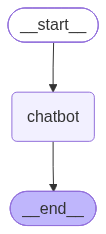

In [76]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [82]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hi!"}]}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content='Hello! How can I help you today? Feel free to ask a question, need advice on something specific, or just chat. 😊', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-09-24T13:29:27.205440631Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3671814051, 'load_duration': 699689, 'prompt_eval_count': 14, 'prompt_eval_duration': 234011000, 'eval_count': 29, 'eval_duration': 3435743000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--01a0d39b-454c-75b3-8958-2dcb93ff8b99-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 29, 'total_tokens': 43})]}
